# Optimization Training Convergence

Two figures: all GA runs and all PSO runs, each showing best score per generation. Runs with fewer than 5 generations or all-zero scores are excluded (crashed runs).


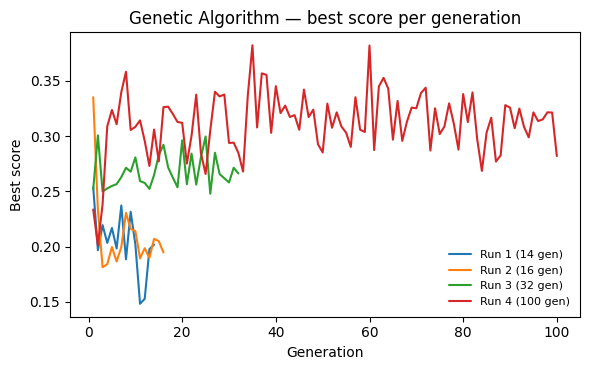

Saved: ../data/ga_convergence.png


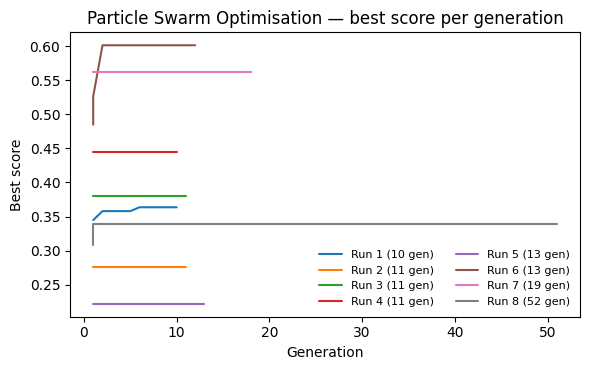

Saved: ../data/pso_convergence.png


In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# plt.rcParams.update({
#     "font.family": "serif",
#     "font.size": 11,
#     "axes.spines.top": False,
#     "axes.spines.right": False,
#     "axes.grid": True,
#     "grid.alpha": 0.25,
#     "grid.linestyle": "--",
# })

MIN_GENS = 5


def load_runs(directory):
    runs = []
    for f in sorted(Path(directory).glob("*.json")):
        data = json.loads(f.read_text())
        scores = [e["best_score"] for e in data]
        gens = [e["generation"] for e in data]
        if len(data) < MIN_GENS or max(scores) == 0:
            continue
        runs.append({"gens": gens, "scores": scores, "n": len(data)})
    runs.sort(key=lambda r: r["n"])
    return runs


base = Path("../data")
ga_runs = load_runs(base / "ga_history")
pso_runs = load_runs(base / "pso_history")


def make_convergence_figure(runs, algo_name, out_path):
    fig, ax = plt.subplots(figsize=(6, 3.8))

    # Color each run from light to dark so longer runs are more prominent
    # cmap = plt.get_cmap("Blues")
    n_runs = len(runs)
    # Longer run = darker line
    for i, run in enumerate(runs):
        shade = 0.35 + 0.55 * (i / max(n_runs - 1, 1))
        # lw = 1.0 + 1.2 * (i / max(n_runs - 1, 1))
        label = f"Run {i + 1} ({run['n']} gen)"
        ax.plot(
            run["gens"],
            run["scores"],
            # color=cmap(shade),
            # linewidth=lw,
            label=label,
            solid_capstyle="round",
        )

    # Annotate the overall best score reached
    # all_scores = [s for r in runs for s in r["scores"]]
    # if all_scores:
        # best = max(all_scores)
        # ax.axhline(best, linewidth=1.0, linestyle=":", alpha=0.8)
        # ax.text(
        #     ax.get_xlim()[1] if ax.get_xlim()[1] > 1 else runs[-1]["gens"][-1],
        #     best + (max(all_scores) - min(all_scores)) * 0.03,
        #     # f"peak = {best:.3f}",
        #     # color="crimson",
        #     fontsize=9,
        #     ha="right",
        # )

    ax.set_xlabel("Generation")
    ax.set_ylabel("Best score")
    ax.set_title(f"{algo_name} — best score per generation")
    ax.legend(
        fontsize=8,
        frameon=False,
        loc="lower right",
        ncol=2 if n_runs > 4 else 1,
    )
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


make_convergence_figure(ga_runs,  "Genetic Algorithm",          base / "ga_convergence.png")
make_convergence_figure(pso_runs, "Particle Swarm Optimisation", base / "pso_convergence.png")
